## Regression Trees

A **regression tree** predicts a *continuous number* (not a class) by splitting the data into regions and predicting the **average value** inside each region.

Take this classic example: how effective is a drug at different **dosages**?

A straight line fits this data terribly — the relationship is *non-linear*. Low doses do nothing, a medium dose works great, and a high dose does nothing again. A regression tree handles this easily by carving the dosage axis into chunks.

For each candidate split at threshold $t$, the tree measures how good the split is using the **sum of squared residuals (SSR)**:

$$SSR = \sum_{\text{left}} (y_i - \bar{y}_{\text{left}})^2 + \sum_{\text{right}} (y_i - \bar{y}_{\text{right}})^2$$

The tree tries every possible threshold and keeps the one with the **smallest SSR**, then repeats on each side.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

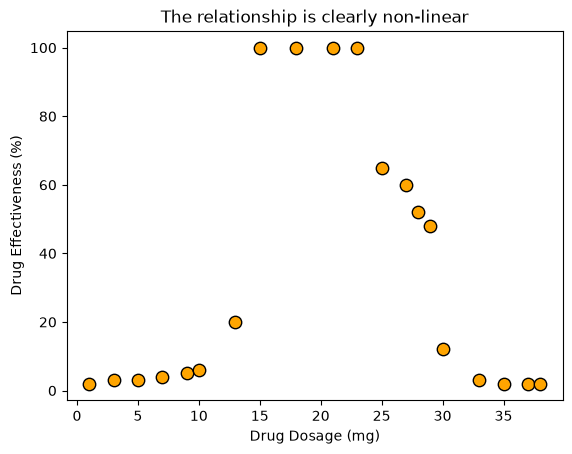

In [3]:
# Drug dosage (mg) vs how effective the drug was (%)
dosage = np.array([
    1, 3, 5, 7, 9, 10, 13,          # low dose  -> barely works
    15, 18, 21, 23,                 # sweet spot -> ~100% effective
    25, 27, 28, 29,                 # a bit too much -> tapering off
    30, 33, 35, 37, 38              # high dose -> back to useless
]).reshape(-1, 1)

effectiveness = np.array([
    2, 3, 3, 4, 5, 6, 20,
    100, 100, 100, 100,
    65, 60, 52, 48,
    12, 3, 2, 2, 2
])

plt.scatter(dosage, effectiveness, color="orange", edgecolor="black", s=80)
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Drug Effectiveness (%)")
plt.title("The relationship is clearly non-linear")
plt.show()

### Fit the tree

We limit the tree's depth so it doesn't split down to a single point per leaf (which would just memorise the data). `max_depth=3` keeps it readable while still capturing the shape.

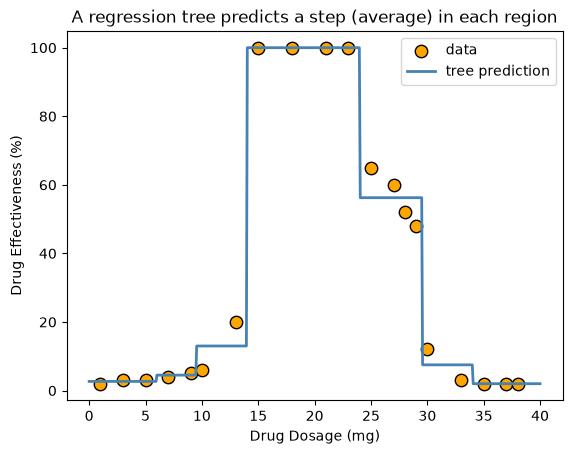

In [4]:
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=2, random_state=0)
tree.fit(dosage, effectiveness)

# Predict across a smooth range of dosages to see the staircase
grid = np.linspace(0, 40, 500).reshape(-1, 1)
preds = tree.predict(grid)

plt.scatter(dosage, effectiveness, color="orange", edgecolor="black", s=80, label="data")
plt.plot(grid, preds, color="steelblue", linewidth=2, label="tree prediction")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Drug Effectiveness (%)")
plt.title("A regression tree predicts a step (average) in each region")
plt.legend()
plt.show()

Notice the prediction is a **staircase**, not a smooth curve. Within each dosage range the tree predicts one flat value — the *average effectiveness* of the training points that fall in that range. That is the defining feature of a regression tree.

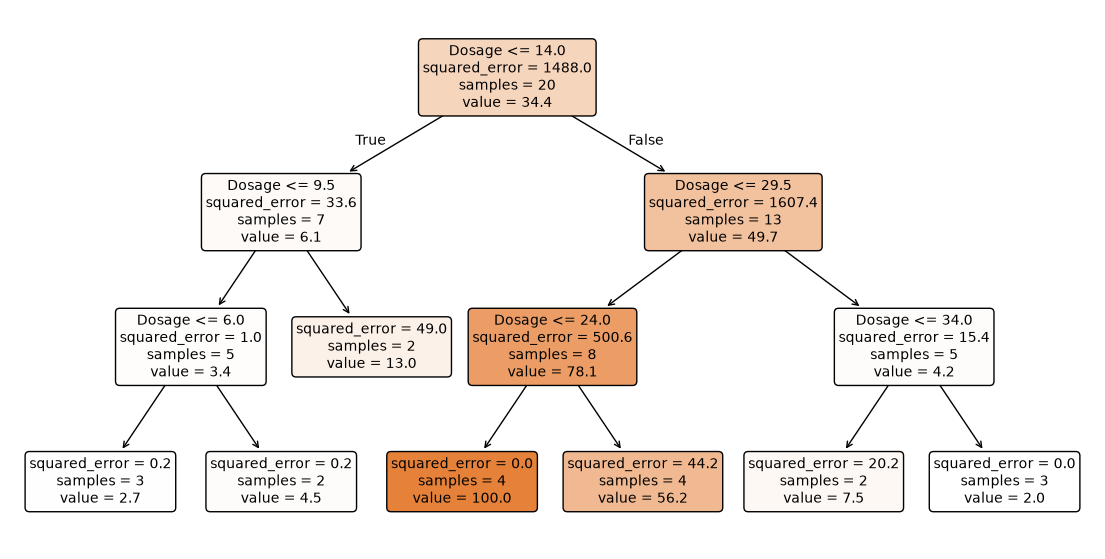

In [5]:
# The actual splits the tree learned
plt.figure(figsize=(14, 7))
plot_tree(
    tree,
    feature_names=["Dosage"],
    filled=True,
    rounded=True,
    precision=1
)
plt.show()

### Reading the tree

Each internal node asks a yes/no question like `Dosage <= 14.0`. Follow the answers down to a **leaf**, and the leaf's `value` is the predicted effectiveness — simply the mean of the training points that landed there.

- `squared_error` on each node is the SSR-based impurity; the tree chose splits that drive it down.
- Deeper trees = more steps = tighter fit, but too deep and the tree **overfits** (memorises noise instead of the trend). `max_depth` and `min_samples_leaf` are the main knobs to control that.

In [6]:
# Predict effectiveness for a few new dosages
for d in [8, 20, 26, 34]:
    print(f"Dosage {d:>2} mg -> predicted effectiveness {tree.predict([[d]])[0]:.1f}%")

Dosage  8 mg -> predicted effectiveness 4.5%
Dosage 20 mg -> predicted effectiveness 100.0%
Dosage 26 mg -> predicted effectiveness 56.2%
Dosage 34 mg -> predicted effectiveness 7.5%
